(59999, 784)
Epoch 0 / 20 : Loss 47.60366540934245 (Recon: 42.56514897054036, Norm: 50.38516453285217)
Epoch 1 / 20 : Loss 43.712188070678714 (Recon: 38.654488953145346, Norm: 50.576991174316404)
Epoch 2 / 20 : Loss 43.528943283081055 (Recon: 38.44617123311361, Norm: 50.827720471191405)
Epoch 3 / 20 : Loss 43.47410438334147 (Recon: 38.361103769429526, Norm: 51.13000605875651)
Epoch 4 / 20 : Loss 43.494551978556316 (Recon: 38.35805545349121, Norm: 51.36496525065104)
Epoch 5 / 20 : Loss 43.507358395385744 (Recon: 38.36736383209229, Norm: 51.39994556274414)
Epoch 6 / 20 : Loss 43.40311258951823 (Recon: 38.30436882578532, Norm: 50.98743753763835)
Epoch 7 / 20 : Loss 43.42610517272949 (Recon: 38.31776058654785, Norm: 51.083445901489256)
Epoch 8 / 20 : Loss 43.40120606384277 (Recon: 38.29332725016276, Norm: 51.07878827107747)
Epoch 9 / 20 : Loss 43.4027750793457 (Recon: 38.28322470143636, Norm: 51.195503455607096)
Epoch 10 / 20 : Loss 43.39836286214193 (Recon: 38.27757939249675, Norm: 51.207

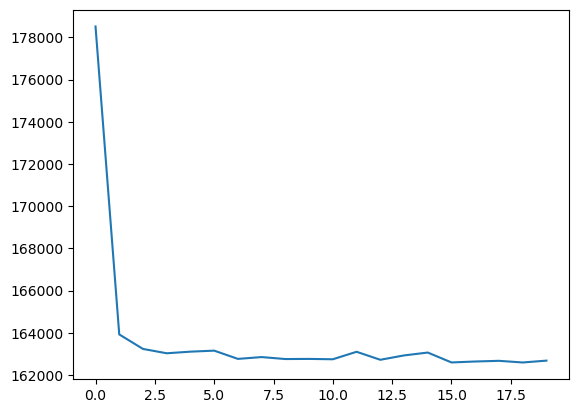

In [58]:
import torch
import pandas as pd
import numpy as np

class ConditionalVAE(torch.nn.Module) :
    def __init__(self, input_dim, embed_dim) :
        super(ConditionalVAE, self).__init__()

        self.input_dim = input_dim
        self.embed_dim = embed_dim

        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 2*embed_dim), # 2 * for the mean and log variance
            torch.nn.ReLU() # Maybe change by a 5*tanh ??
        )

        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(embed_dim, input_dim, bias=False),
            torch.nn.Sigmoid() # Because we ll predict the pixel 's color between 0 and 1
        )
        #self.decoder[0].bias.data.fill_(-0.822894092)
    
    def encode(self, x) :
        '''
        x: torch.Tensor (B, input_dim)
        Output: a tuple (torch.Tensor (B, embed_dim), torch.Tensor (B, embed_dim)) the first value is the mean and the second one the log-variance
        '''
        tmp = self.encoder(x)
        means   = tmp[..., :self.embed_dim]
        logvar  = tmp[..., self.embed_dim:]
        return (means, logvar)

    def decode(self, z) :
        '''
        z: torch.Tensor(B, embed_dim)
        Output: decoded z
        '''
        return self.decoder(z)+0.1307

    def forward(self, x) :
        '''
        The forward use for inference so we dont add noise and just take the mean
        x: torch.Tensor (B, input_dim)
        Output: torch.Tensor (B, input_dim) the encoded and decoded x
        '''
        means, _ = self.encode(x)
        return self.decode(means)
    
    def sample(self, n):
        z = torch.randn(n, self.embed_dim)
        return self.decode(z)

    def forward_train(self, x) :
        """
        x: torch.Tensor (B, input_dim)
        Output: A triplet (x encoded and decoded(B, input_dim), means((B, embed_dim)), logvars(B, embed_dim))
        """
        eps = torch.randn((x.shape[0], self.embed_dim)) # eps ~ N(0, 1)
        means, logvar = self.encode(x)
        z = means + eps*torch.exp(logvar/2.0) # z ~ N(mean, var)
        return (self.decode(z), means, logvar)

    def fit(self, data, batch_size=16, epochs=20, lr=4e-3) :
        dataloader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        criterion_recon = torch.nn.MSELoss()
        all_losses = []
        all_loss_recon = []
        all_loss_norm = []
        beta=0.1
        for epoch in range(epochs) :
            loss_epoch = 0.0
            loss_recon_epoch = 0.0
            loss_norm_epoch = 0.0
            for x in dataloader :
                optimizer.zero_grad()
                x_hat, means, logvars = self.forward_train(x)
                #loss_recon = criterion_recon(x, x_hat)
                loss_recon = torch.sum((x - x_hat)**2)/x.shape[0] # We normalize by the number of batches
                loss_norm = -0.5 * torch.sum(1 + logvars - means.pow(2) - logvars.exp()) / x.shape[0]
                loss = beta*loss_norm + loss_recon
                loss.backward()
                optimizer.step()
                loss_norm_epoch += loss_norm.item()
                loss_recon_epoch += loss_recon.item()
                loss_epoch += loss.item()

            print(f"Epoch {epoch} / {epochs} : Loss {loss_epoch/len(dataloader)} (Recon: {loss_recon_epoch/len(dataloader)}, Norm: {loss_norm_epoch/len(dataloader)})")
            all_loss_norm.append(loss_norm)
            all_loss_recon.append(loss_recon)
            all_losses.append(loss_epoch)
        import matplotlib.pyplot as plt
        plt.plot(np.array(all_losses))
        plt.show()     
        
data = pd.read_csv('/home/thibault/NN/MNIST/MNIST2/mnist_train.csv').iloc[:,1:]
print(data.shape)
data_torch = torch.Tensor(data.to_numpy(dtype=float))/255.0

vae = ConditionalVAE(input_dim=784, embed_dim=32)
vae.fit(data_torch, epochs=20)


In [59]:
vae.decoder[0].bias

In [ ]:
bias_before=vae.decoder[0].bias

Parameter containing:
tensor([-6.9377, -6.6188, -6.8665, -6.6255, -6.8429, -6.6581, -6.6743, -6.7810,
        -6.5673, -6.7119, -6.7140, -6.8533, -6.6276, -6.6917, -6.9451, -6.5935,
        -6.7546, -6.7369, -6.7274, -6.7463, -6.8423, -6.7225, -6.6020, -6.7379,
        -6.5543, -6.8941, -6.7784, -6.6744, -6.6890, -6.7673, -6.6640, -6.6648,
        -6.6022, -6.6839, -6.8945, -6.8493, -6.6073, -6.7687, -6.6106, -6.4147,
        -6.4785, -6.0537, -5.7146, -6.0050, -5.9264, -6.3841, -6.5704, -6.8491,
        -6.7952, -6.5465, -6.5789, -6.7396, -6.7531, -6.7393, -6.7158, -6.6345,
        -6.6939, -6.5696, -6.7403, -6.7511, -6.8253, -6.7245, -7.0299, -6.7395,
        -6.7023, -6.0083, -5.7688, -5.1552, -4.9182, -4.9108, -4.3738, -3.9886,
        -3.9750, -4.3297, -4.5732, -5.4399, -6.2296, -6.1929, -6.4683, -6.5456,
        -6.4599, -6.6451, -6.5113, -6.8461, -6.8269, -6.6630, -6.7627, -6.8445,
        -6.5248, -6.9499, -6.8030, -6.5337, -6.4305, -6.0243, -5.6120, -5.3207,
        -4.9703, -

Check reconstruction vs original


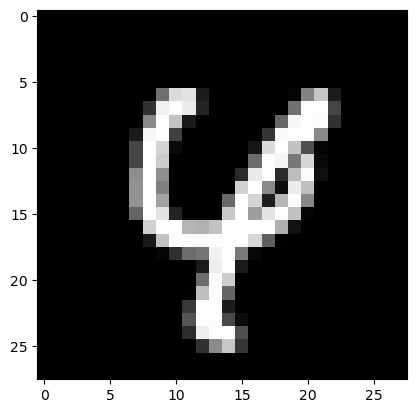

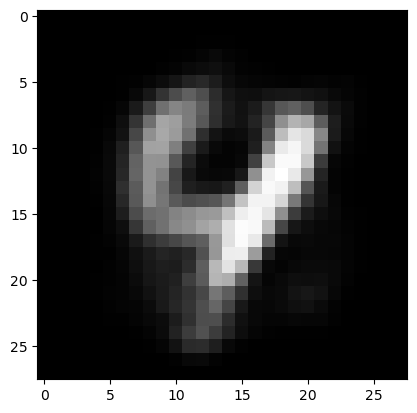

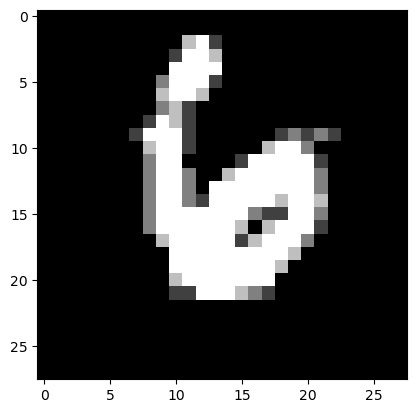

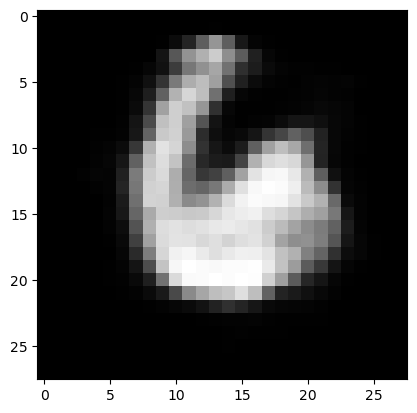

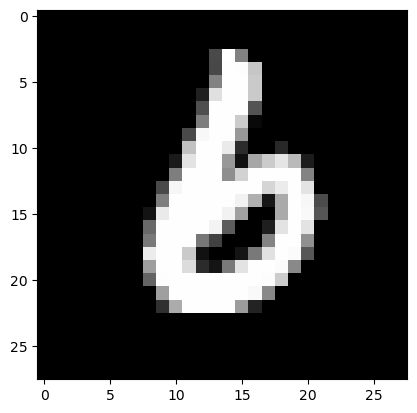

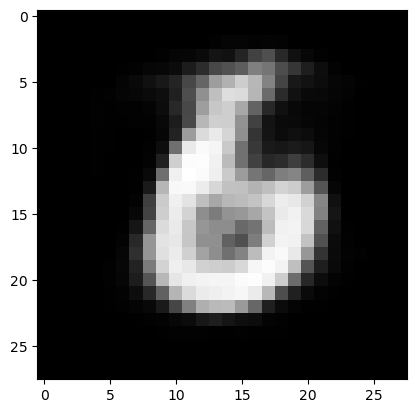

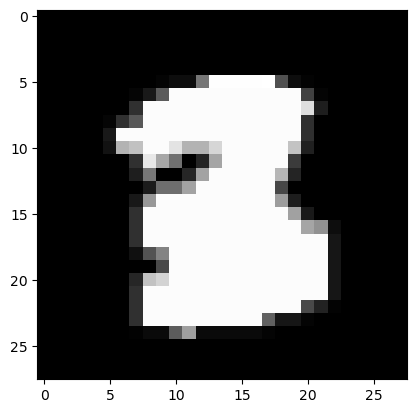

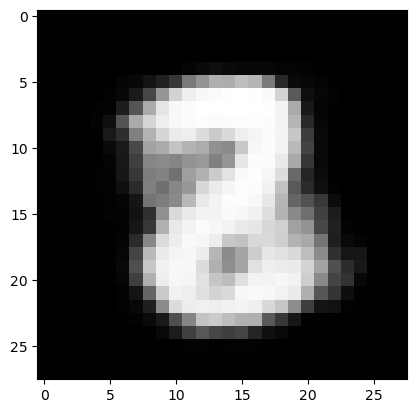

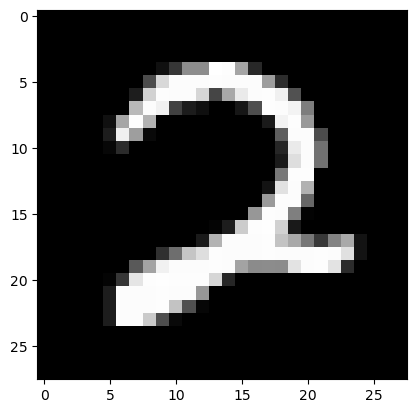

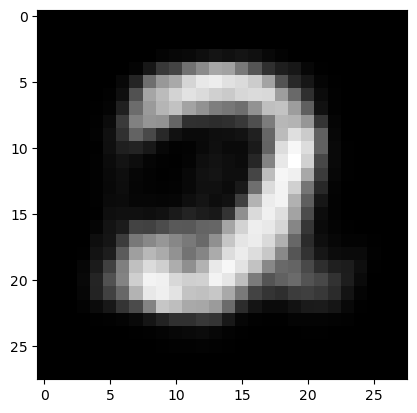

Generate new samples


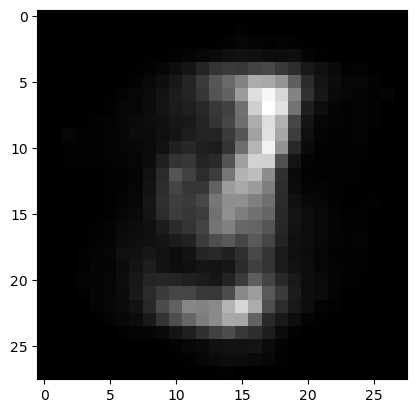

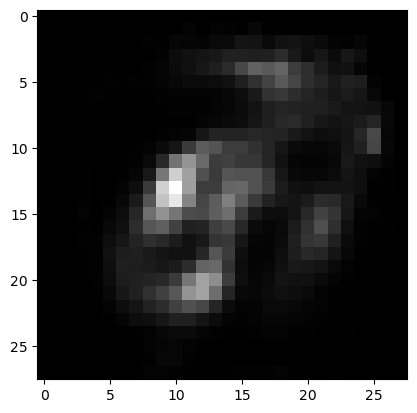

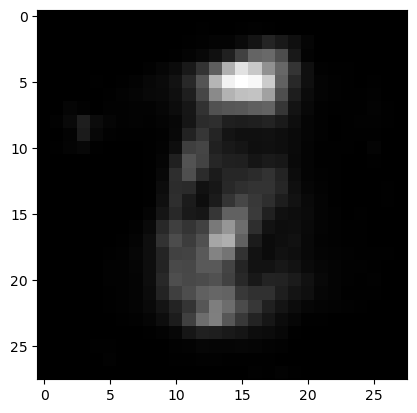

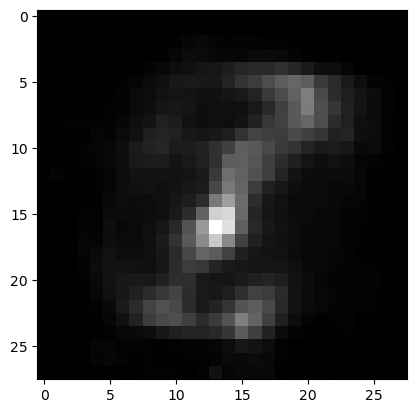

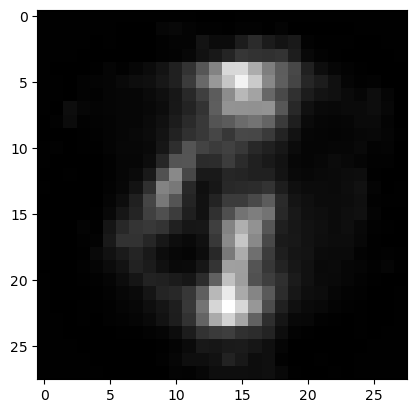

In [43]:
# now we test the VAE

num_samples = 5
samples = torch.randint(0, len(data_torch), (num_samples,))
generated = vae.forward(data_torch[samples])

print("Check reconstruction vs original")
for i in range(num_samples) :
    import matplotlib.pyplot as plt
    plt.imshow(data_torch[samples[i]].detach().numpy().reshape((28,28)), cmap='gray')
    plt.show()
    plt.imshow(generated[i].detach().numpy().reshape((28,28)), cmap='gray')
    plt.show()

print("Generate new samples")
new_samples = vae.sample(num_samples)
for i in range(num_samples) :
    import matplotlib.pyplot as plt
    plt.imshow(new_samples[i].detach().numpy().reshape((28,28)), cmap='gray')
    plt.show()

In [54]:
embeddings = vae.encode(data_torch)[0].detach().numpy() # The embeddings of the whole dataset
print(embeddings.shape)
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=10)
clusters = kmeans.fit_predict(embeddings)
full_data = pd.read_csv('/home/thibault/NN/MNIST/MNIST2/mnist_train.csv')

for i in range(10) :
    idx = np.where(clusters == i)[0]
    print(f"Cluster {i} has {len(idx)} elements")
    # print the most representative class amoung the cluster
    classes = full_data.iloc[idx,0]
    unique, counts = np.unique(classes, return_counts=True)
    most_representative_class = unique[np.argmax(counts)]
    print(f"Most representative class is {most_representative_class} with {np.max(counts)} elements")

(59999, 32)
Cluster 0 has 3857 elements
Most representative class is 7 with 3442 elements
Cluster 1 has 10213 elements
Most representative class is 1 with 6623 elements
Cluster 2 has 5222 elements
Most representative class is 0 with 1497 elements
Cluster 3 has 8041 elements
Most representative class is 4 with 3336 elements
Cluster 4 has 6859 elements
Most representative class is 9 with 2272 elements
Cluster 5 has 4099 elements
Most representative class is 0 with 3854 elements
Cluster 6 has 4598 elements
Most representative class is 2 with 3991 elements
Cluster 7 has 7776 elements
Most representative class is 3 with 4447 elements
Cluster 8 has 4976 elements
Most representative class is 8 with 3634 elements
Cluster 9 has 4358 elements
Most representative class is 6 with 3751 elements
